In [1]:
import sys
print(sys.executable)


C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\.venv\Scripts\python.exe


In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from math import radians, sin, cos, sqrt, atan2
import seaborn as sns

In [3]:
df_ciudades =pd.read_csv("../data/clean/dim_geografia_es_latlon_osm.csv")

In [4]:
df_ciudades[["lat", "lng"]].dtypes



lat    float64
lng    float64
dtype: object

# ¿Cuál es el número total de municipios únicos incluidos en el dataset final?

In [5]:
# Conteo de registros únicos por id_municipio.
total_filas = df_ciudades.shape[0]
print("Total filas",{total_filas})
municipios_unicos = df_ciudades["id_municipio"].nunique()
print("Municipios unicos",{municipios_unicos})
duplicados = total_filas - municipios_unicos
print("Duplicados",{duplicados})


Total filas {8132}
Municipios unicos {8132}
Duplicados {0}


In [6]:
# Municipios sin coordenadas geográficas
nulos_geo = df_ciudades[df_ciudades["lat"].isna() | df_ciudades["lng"].isna()]

# Conteo de nulos por provincia
nulos_por_provincia = (
    nulos_geo.groupby("provincia")
    .size()
    .reset_index(name="municipios_sin_latlng")
    .sort_values("municipios_sin_latlng", ascending=False)
)

nulos_por_provincia


,provincia,municipios_sin_latlng


In [7]:
coord_por_municipio = (
    df_ciudades
    .groupby("id_municipio")[["lat", "lng"]]
    .nunique()
    .reset_index()
)
# Municipios con más de una lat o lng distinta
coord_incosistencias = coord_por_municipio[
    (coord_por_municipio["lat"]>1) | (coord_por_municipio["lng"]>1)
]
coord_incosistencias

print("Municipios con coordenadas inconsistentes:", coord_incosistencias.shape[0])


Municipios con coordenadas inconsistentes: 0


El análisis de integridad del dataset confirma que cada fila corresponde a un municipio único, sin presencia de registos duplicado o nulos. En total, el conjunto de datos contiene 8.132 municipios, coincidiendo el número de filas con el número de identificadores únicos, lo que garantiza una consistencia estructural del dataset.adicionalmente se puede confirmar que el dataset cuenta con coordenadas geográficas únicas asociadas. Lo cual asegura coherencia y permite el cálculo fiable de distancias geográficas mediante métricas como la fórmula de Haversine

# ¿Cuántas provincias comunidades autónomas y ciuadades están representadas?

In [8]:
num_provincias = df_ciudades["provincia"].nunique()
num_ccaa = df_ciudades["comunidad autonoma"].nunique()
num_ciudades = df_ciudades["nombre"].nunique()
num_isla = df_ciudades["isla"].nunique()

print(f"Número de provincias: {num_provincias}")
print(f"Número de comunidades autónomas: {num_ccaa}")
print(f"Número de ciudades: {num_ciudades}")
print(f"Número de islas: {num_isla}")


Número de provincias: 52
Número de comunidades autónomas: 19
Número de ciudades: 8115
Número de islas: 12


El dataset geográfico final contiene información correspondiente a 52 provincias, 19 comunidades autónomas, 8.115 municipios y 12 islas, lo que confirma una cobertura territorial completa del ámbito español.
Este resultado valida la idoneidad del conjunto de datos como base geográfica para el desarrollo del proyecto, garantizando la representatividad administrativa y territorial necesaria para el análisis espacial y la generación de recomendaciones turísticas a escala nacional.

# ¿Cómo se distribuyen los municipios entre las distintas comunidades autónomas de España?

In [9]:
ccaa_counts = (
    df_ciudades
    .groupby("comunidad autonoma", as_index=False)
    .size()
    .rename(columns={"size": "total_municipios"})
    .sort_values("total_municipios", ascending=False)
)

In [10]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

<Figure size 1200x700 with 0 Axes>

<Figure size 1200x700 with 0 Axes>

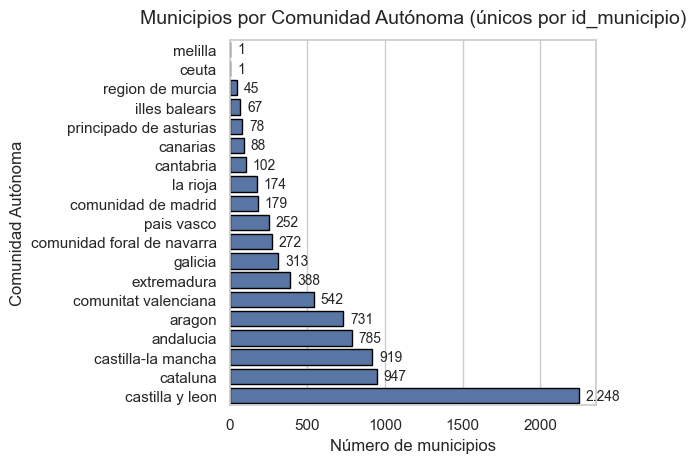

In [11]:
# Ordenar categorías por el conteo
order = ccaa_counts["comunidad autonoma"].tolist()[::-1]  # para barra horizontal ascendente visual
ax = sns.barplot(
    data=ccaa_counts,
    y="comunidad autonoma",
    x="total_municipios",
    order=order,
    color="#4C72B0",
    edgecolor="black"
)
# Etiquetas y título
ax.set_title("Municipios por Comunidad Autónoma (únicos por id_municipio)", fontsize=14, pad=12)
ax.set_xlabel("Número de municipios", fontsize=12)
ax.set_ylabel("Comunidad Autónoma", fontsize=12)

# Anotar valores al final de cada barra
for p in ax.patches:
    valor = int(p.get_width())
    ax.annotate(f"{valor:,}".replace(",", "."),
                (p.get_x() + p.get_width(), p.get_y() + p.get_height()/2),
                xytext=(5, 0), textcoords="offset points",
                va="center", ha="left", fontsize=10)

plt.tight_layout()
# Guardar y mostrar
plt.savefig("municipios_por_ccaa.png", dpi=150)
plt.show()


Este análisis proporciona una base objetiva para adaptar el sistema de recomendación turística a la estructura territorial de cada comunidad autónoma, permitiendo ajustar el nilvel de granulidad de las recomendacion y optimizar la planificación de rutas culturales en función de la complejidad administrativa del territorio.

# Revisión de la estructura insulas de España

In [12]:
df_unicos = df_ciudades.drop_duplicates(subset=["isla"])
# Conteo por CCAA (ordenado desc)
ccaa_counts = (
    df_unicos
    .groupby("comunidad autonoma", as_index=False)
    .size()
    .rename(columns={"size": "total_islas"})
    .sort_values("total_islas", ascending=False)
)


In [13]:
# ---------------------------
# 3) Gráfico de barras
# ---------------------------
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

<Figure size 1200x700 with 0 Axes>

<Figure size 1200x700 with 0 Axes>

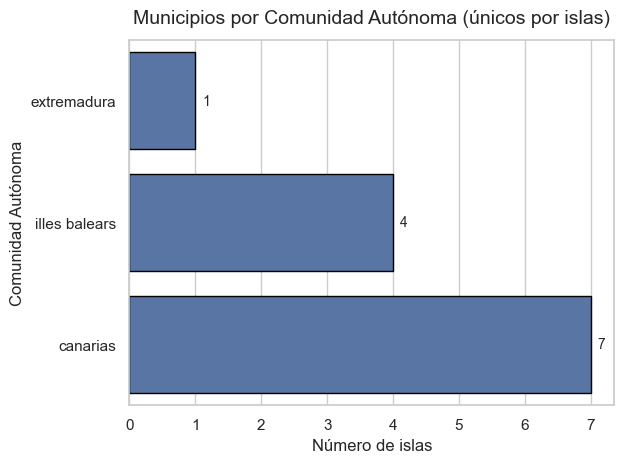

In [14]:
# Ordenar categorías por el conteo
order = ccaa_counts["comunidad autonoma"].tolist()[::-1]  # para barra horizontal ascendente visual
ax = sns.barplot(
    data=ccaa_counts,
    y="comunidad autonoma",
    x="total_islas",
    order=order,
    color="#4C72B0",
    edgecolor="black"
)

# Etiquetas y título
ax.set_title("Municipios por Comunidad Autónoma (únicos por islas)", fontsize=14, pad=12)
ax.set_xlabel("Número de islas", fontsize=12)
ax.set_ylabel("Comunidad Autónoma", fontsize=12)

# Anotar valores al final de cada barra
for p in ax.patches:
    valor = int(p.get_width())
    ax.annotate(f"{valor:,}".replace(",", "."),
                (p.get_x() + p.get_width(), p.get_y() + p.get_height()/2),
                xytext=(5, 0), textcoords="offset points",
                va="center", ha="left", fontsize=10)

plt.tight_layout()

# Guardar y mostrar
plt.savefig("islas_por_ccaa.png", dpi=150)
plt.show()

El siguiente análisis permite al sistema de recomendación turística adaptar la planificación de itinerarios, evitando la generación de rutas inviables por vía terreste y considerando la singularidad lógistica de los archipiélagos

# ¿Existen coordenadas geográficas atípicas o erróneas?

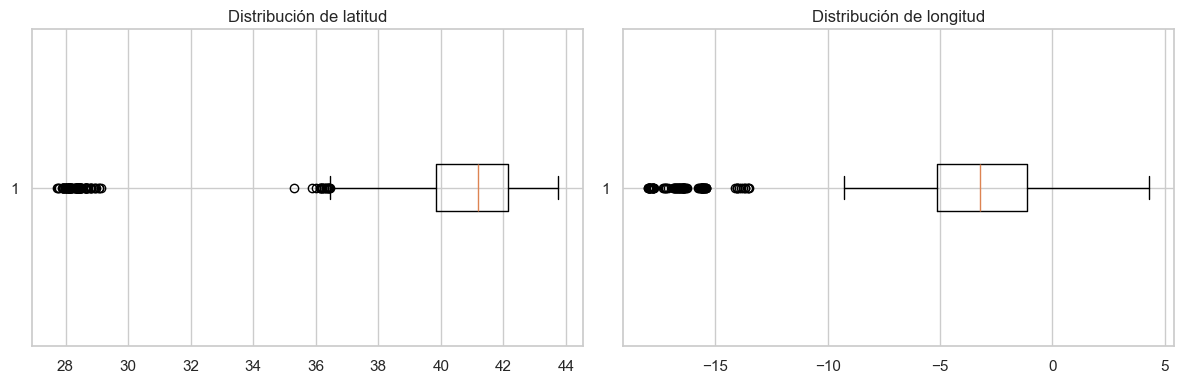

In [15]:
# Análisis de rangos válidos para España (latitudes y longitudes).
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df_ciudades["lat"], vert=False)
axes[0].set_title("Distribución de latitud")

axes[1].boxplot(df_ciudades["lng"], vert=False)
axes[1].set_title("Distribución de longitud")

plt.tight_layout()
plt.show()

### Analisis de Latitud
La mayoría de municipios se concentran aproximadamente entre 39° y 42° N
→ corresponde a la Península Ibérica
Aparece un grupo claro de valores más bajos, alrededor de 27–29° N
→ Islas Canarias
### Analisis Longitud
La mayor concentración está entre -6 y 2 grados
→ Península + Baleares
Se detecta un grupo de valores claramente más negativos (-18 a -13)
→ Canarias
No aparecen longitudes fuera del ámbito español

In [16]:
fuera_espana = df_ciudades[
    ~(
        # Península
        ((df_ciudades["lat"].between(36, 44)) &
         (df_ciudades["lng"].between(-9, 3))) |

        # Baleares
        ((df_ciudades["lat"].between(38, 40)) &
         (df_ciudades["lng"].between(1, 4))) |

        # Canarias
        ((df_ciudades["lat"].between(27, 29)) &
         (df_ciudades["lng"].between(-18, -13))) |

        # Ceuta
        ((df_ciudades["lat"].between(35.8, 36.1)) &
         (df_ciudades["lng"].between(-5.5, -5.1))) |

        # Melilla
        ((df_ciudades["lat"].between(35.2, 35.5)) &
         (df_ciudades["lng"].between(-3.1, -2.8)))
    )
]


In [17]:
fuera_espana = fuera_espana.copy()

# ¿Qué CCAA aparecen en los fuera de rango?
fuera_espana["comunidad autonoma"].value_counts().head(20)
fuera_espana[["comunidad autonoma","provincia","lat","lng"]].head(30)


,comunidad autonoma,provincia,lat,lng
646,galicia,a coruna,43.131150,-9.181720
650,galicia,a coruna,42.855080,-9.091790
653,galicia,a coruna,42.954660,-9.188000
657,galicia,a coruna,42.944140,-9.192600
663,galicia,a coruna,43.008360,-9.113280
666,galicia,a coruna,42.904920,-9.262890
669,galicia,a coruna,43.183330,-9.016670
681,galicia,a coruna,43.104140,-9.217910
682,galicia,a coruna,42.776170,-9.060320
965,cataluna,girona,42.103890,3.084330


In [18]:
fuera_espana = df_ciudades[
    ~(
        # Península (incluye Galicia occidental)
        ((df_ciudades["lat"].between(35.5, 44.5)) &
         (df_ciudades["lng"].between(-9.5, 4.5))) |

        # Baleares (incluye Mallorca y Menorca)
        ((df_ciudades["lat"].between(38.5, 40.3)) &
         (df_ciudades["lng"].between(1.0, 4.5))) |

        # Canarias
        ((df_ciudades["lat"].between(27.0, 29.6)) &
         (df_ciudades["lng"].between(-18.5, -13.0))) |

        # Ceuta
        ((df_ciudades["lat"].between(35.8, 36.1)) &
         (df_ciudades["lng"].between(-5.5, -5.1))) |

        # Melilla
        ((df_ciudades["lat"].between(35.2, 35.5)) &
         (df_ciudades["lng"].between(-3.1, -2.8)))
    )
]

print("Municipios fuera de rangos esperados:", fuera_espana.shape[0])


Municipios fuera de rangos esperados: 0


El análisis de rango mediante boxplot confirma que las coordenadas geográficas del dataset se encuentran de los límites esperados dentro del territorio español. Los valores extremos identificados corresponden a territorios insulares, como Canarias y no a errores de Geocodificación, lo que valida la coherencia espacial del conjunto de datos.

La detección inicial de municipios fuera de los rangos definidos se debio a una delimitación geográfica excesivamente restrictiva. Tras ajustar los rango para incorporar zonas costeras y territorios extremos como Galicia occidential y las islas Baleares, se confirma que el 100% de los municipios presentan coordenadas coherentes con su ubicación real en el territorio español

# ¿Cuál es la distribución espacial de los municipios en el territorio español?

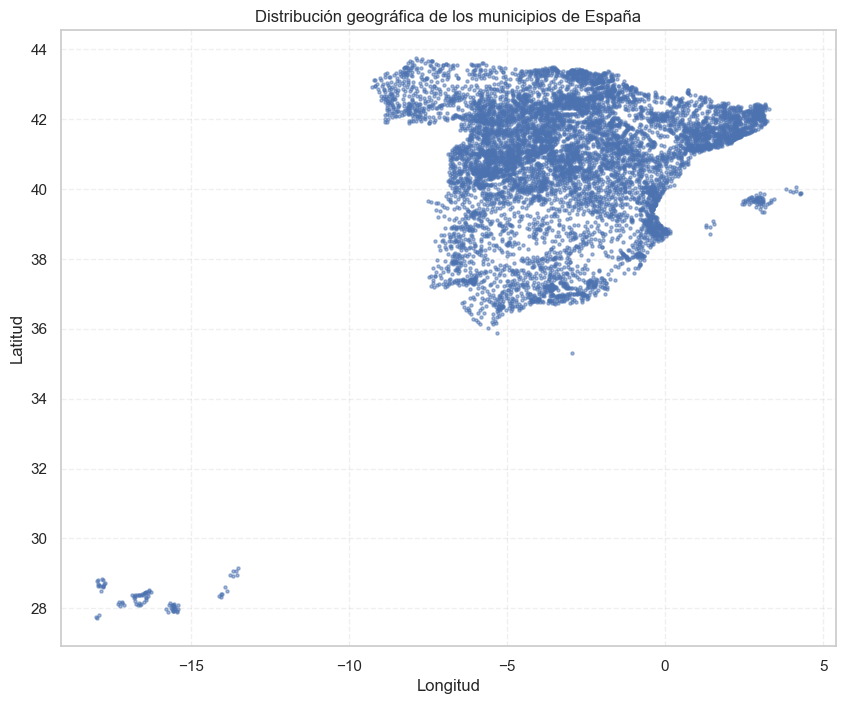

In [19]:
plt.figure(figsize=(10, 8))

plt.scatter(
    df_ciudades["lng"],
    df_ciudades["lat"],
    s=5,
    alpha=0.5
)

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Distribución geográfica de los municipios de España")

plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

#### El diagrama de dispersión muestra:
La Península Ibérica claramente definida en el centro del gráfico
Las Islas Baleares separadas al este
Las Islas Canarias claramente aisladas al suroeste
No hay puntos fuera del territorio español

Esta validación visual demuestra la idoneidad del dataset como base geográfica para el cálculo de distancias, la planificación de rutas culturales y el diseño de un sistema de recomendación turística en proximidad geográfica

# ¿Cuál es la distancia media entre municipios dentro de una misma provincia?

In [20]:
#Paso 1 preparar datos númericos
df = df_ciudades.copy()
df["lat"] = df["lat"].astype(float)
df["lng"] = df["lng"].astype(float)

In [21]:
# Paso 2 Calcular punto promedio central
centroides = (
    df.groupby("provincia")[["lat","lng"]]
    .mean()
    .rename(columns={"lat":"lat_c","lng":"lng_c"})
)

In [22]:
# Paso 3 Crear el calculo Haversine el cual es una fórmula utilizada para calcular la distancia entre dos puntos de una esfera dadas sus coordenadas de longitud y latitud.
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km radio de la tierra
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2  #-> calculan el ángulo central entre dos puntos sobre la superficie de una esfera
    c = 2 * atan2(sqrt(a), sqrt(1 - a)) #-> es el ángulo central entre los dos puntos, expresado en radianes.
    return R * c

In [23]:
# Paso 4 Distancia de cada municipio a su centroide
df = df.merge(centroides, on="provincia")

df["dist_centroide_km"] = df.apply(
    lambda x: haversine(x["lat"], x["lng"], x["lat_c"], x["lng_c"]),
    axis=1
)
"dist_centroide_km" in df.columns


True

In [24]:
#Dispersión media por provincia
dispersion = (
    df.groupby("provincia")["dist_centroide_km"]
    .mean()
    .sort_values(ascending=False)
)


El cálculo de distancias Haversine se realizó a nivel provincial, tomando como referencia el centroide geodráfico de cada provincia y midiendo la distancia media de los municipios a dicho punto. Este enfoque permitió analizar tanto el valor promedio como la dispersión territorial, identificando provincias compactas y altamente dispersias, información clave para el diseño de itinerarios turísticos eficientes.
Se calcula un centroide provincial (punto medio matemático)
Se mide qué tan lejos están, en promedio, los municipios de ese punto.

# ¿Cómo varía la accesibilidad territorial entre regiones?

In [25]:
distancia_media_ccaa = (
    df.groupby("comunidad autonoma")["dist_centroide_km"]
      .mean()
      .sort_values(ascending=False)
)

distancia_media_ccaa


comunidad autonoma
canarias                      71.140044
principado de asturias        58.089433
extremadura                   53.792309
aragon                        48.373249
castilla-la mancha            47.588946
illes balears                 42.861133
comunitat valenciana          40.314749
andalucia                     40.108690
castilla y leon               39.405414
comunidad de madrid           39.150522
comunidad foral de navarra    37.591183
cataluna                      37.179789
galicia                       35.626671
region de murcia              30.159554
cantabria                     29.413867
la rioja                      27.008919
pais vasco                    18.878366
ceuta                          0.000000
melilla                        0.000000
Name: dist_centroide_km, dtype: float64

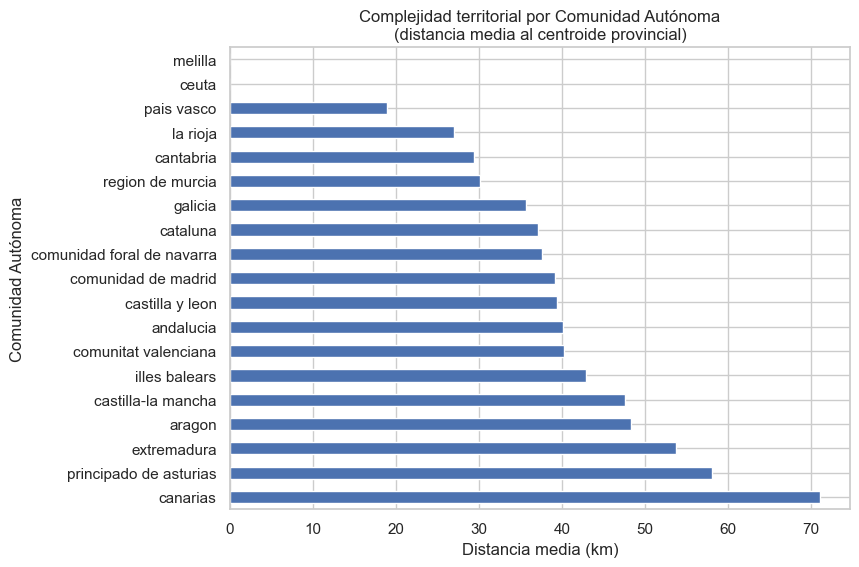

In [26]:
import matplotlib.pyplot as plt

distancia_media_ccaa.plot(
    kind="barh",
    figsize=(8,6),
    title="Complejidad territorial por Comunidad Autónoma\n(distancia media al centroide provincial)",
)

plt.xlabel("Distancia media (km)")
plt.ylabel("Comunidad Autónoma")
plt.show()


Las comunidades autónomas con mayores valores de distancia media al centroide presentan una mayor dispersión geográfica de sus municipios, lo que implica una mayor complejidad territorial. Este patrón es especialmente relevante para el diseño de itinerarios turísticos, ya que regiones más dispersas requieren rutas más largas y una planificación espacial más cuidadosa, mientras que regiones más compactas permiten recomendaciones más concentradas.

## Gráfico: provincias más y menos dispersas

### Top 10 provincias más dispersas

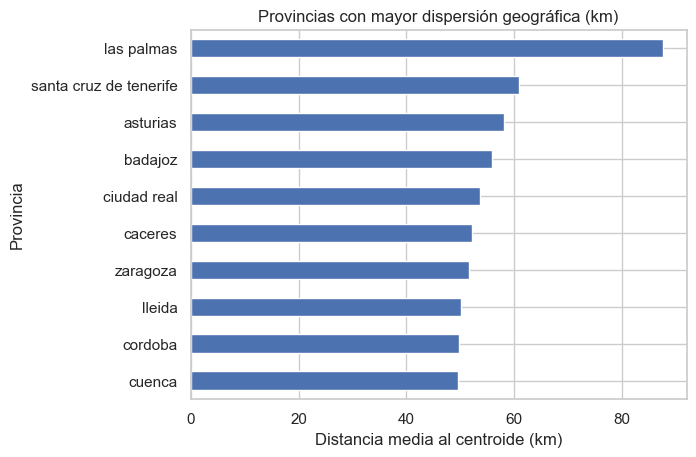

In [27]:

dispersion.head(10).plot(
    kind="barh",
    title="Provincias con mayor dispersión geográfica (km)",
    xlabel="Distancia media al centroide (km)",
    ylabel="Provincia",
)
plt.gca().invert_yaxis()
plt.show()

El gráfico identifica las provincias con mayor dispersión geográfica, entendida como una mayor distancia media de sus municipios respecto al cetroide provincial. Estas provincias presentan una estructura más extendida, por lo tanto desde la prespectiva del sistema de recomendación, estas provincias requiren estrategias de planificación más selectivas, priorizando rutas optimizadas y limitando el número de desplazamientos.

### Top 10 provincias mas cercanas

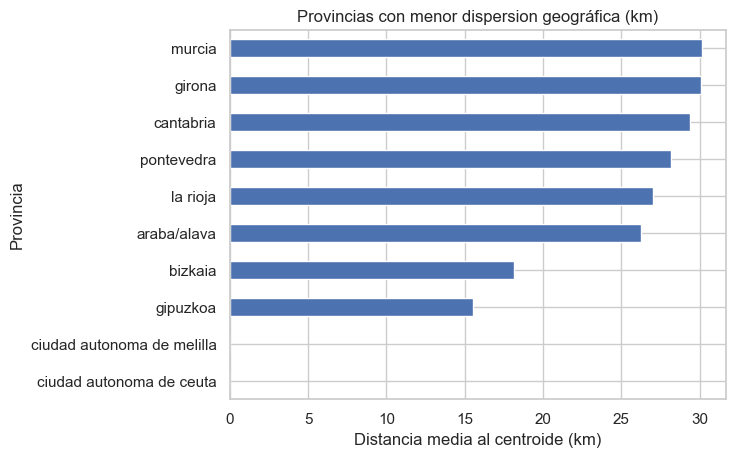

In [28]:
dispersion.tail(10).plot(
    kind="barh",
    title="Provincias con menor dispersion geográfica (km)",
    xlabel = "Distancia media al centroide (km)",
    ylabel = "Provincia"
)
plt.gca().invert_yaxis()
plt.show()


Las provicias con menor dispersión geográfica presentan una menor distancia media de sus municipios respecto al centroide provincial, lo que indica una mayor concentración territorial. por lo tanto permite al sistema de recomendación a planificar intenerarios culturales con múltiples paradas cercanas, al reducir los desplazamientos necesarios entre destinos.

In [29]:
municipios_centrales = (
    df.loc[df.groupby("provincia")["dist_centroide_km"].idxmin()]
    [["provincia", "nombre", "dist_centroide_km"]]
    .sort_values("dist_centroide_km")
)

municipios_centrales.head(10)


,provincia,nombre,dist_centroide_km
7054,ciudad autonoma de ceuta,Ceuta,0.000000
7151,ciudad autonoma de melilla,Melilla,0.000000
1672,gipuzkoa,Bidania-Goiatz,0.561436
3950,palencia,Villalcázar de Sirga,0.570993
4519,cantabria,Corvera de Toranzo,0.739932
5321,tarragona,Riudecols,1.044947
6361,bizkaia,Larrabetzu,1.187874
976,girona,Banyoles,1.200156
1499,guadalajara,Masegoso de Tajuña,1.272837
2385,leon,Villadangos del Páramo,1.354358


In [30]:
df = df_ciudades.copy()

df["zona"] = "Península"

df.loc[
    (df["isla"].notna()) &
    (df["isla"].str.lower() != "no aplica") &
    (df["comunidad autonoma"] == "illes balears"),
    "zona"
] = "Baleares"

df.loc[
    (df["isla"].notna()) &
    (df["isla"].str.lower() != "no aplica") &
    (df["comunidad autonoma"] == "canarias"),
    "zona"
] = "Canarias"

df["zona"].value_counts()


zona
Península    7977
Canarias       88
Baleares       67
Name: count, dtype: int64

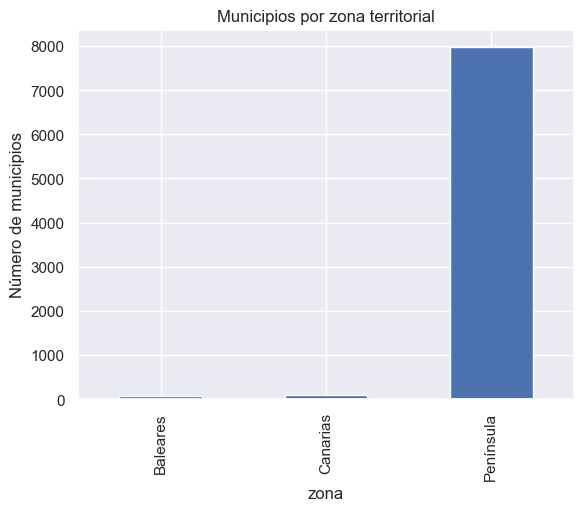

In [31]:
conteo_zona = df.groupby("zona")["id_municipio"].nunique()

conteo_zona.plot(kind="bar", title="Municipios por zona territorial")
plt.ylabel("Número de municipios")
plt.show()

El análisis del número de municipios por zona territorial pone de manifiesto una fuerta asimetría en la estructura administrativa española. La Penpinsula concentra la práctica totalidad de los municipios, reflejando una elevada fragmentación territorial y una continuidad geográfica que facilita el diseño de itinerarios terrestres extensos.
En contraste, Baleares y Canarias presentan un número significante menor de municipios y una distribución insular, lo que introduce restricciones logísticas relevantes para la planificación de rutas. Estas estadísticas justifican la necesidad de adaptar el sistema de recomendación turística a la realidad territorial de cada zona, incorporando segmentación por isla en los territorios insulares y evitando enfoques homogéneos a nivel nacional